# Projeto de Análise de Dados EDA e respondendo perguntas sobre negócios no dataset Nykaa

## 1 O que é o dataset Nykaa?

 O Nykaa é um dataset de uma empresa de produtos de beleza e bem-estar da Índia.

 Este dataset não foca nos produtos da empresa e sim em seu marketing.

 O marketing de campanhas contém registros no período entre Junho de 2024 até Junho de 2025.

 O dataset compõe 5 tipos de campanhas, 6 canais de comunicação, 5 segmentos de público e 4 idiomas.

 Os tipos de campanha são Social Media, SEO, Email, Influencer e Paid Ads.

 Os canais usados são Youtube, Google, Whatsapp, Instagram, Email e Facebook.

 Os segmentos de público são  Working Woman, College Students, Tier 2 City Customers, Premium Shoppers e Youth.

 Os idiomas falados são Bengali, English, Hindi e Tamil.

 O dataset foi obtido no Kaggle e pode ser sintético, dado que os valores apresentam uma distribuição muito uniforme entre categorias.

## 2 Quais são os objetivos da análise no dataset?

 Os objetivos da análise contém desde a EDA (Análise Exploratória de Dados) observando a performance das campanhas, como o público reage e a eficiência dos canais de comunicação,
 até a criação e análise de métricas de negócios de marketing como ROI, CTR, Conversion_Rate dentre outros.

## 3 O que quis responder com as análises?

 O que quis responder com as análises feitas neste projeto é entender quais campanhas e canais geram maior retorno e identificar onde há perda de performance.

 Além disso, buscou-se entender se o problema de campanhas com ROI negativo é um problema pontual ou estrutural e como a performance se comporta ao longo do tempo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("nykaa_campaign_data.csv")

display(df.info())
display(df)
display(list(df.columns))
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  str    
 1   Campaign_Type     55555 non-null  str    
 2   Target_Audience   55555 non-null  str    
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  str    
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  str    
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  str    
 15  Date              55555 non-null  str    
dtypes: float64(3), int64(6), str(7)
memory usage: 6.8 M

None

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55550,NY-CMP-56550,SEO,Youth,16,"Instagram, Email",31041,3849,1012,639,162945,374.90,-0.32,Tamil,17.72,Tier 2 City Customers,16-02-2025
55551,NY-CMP-56551,Paid Ads,Tier 2 City Customers,26,Facebook,27335,3715,2184,1006,792728,56.38,12.98,English,25.26,Premium Shoppers,18-11-2024
55552,NY-CMP-56552,Influencer,Tier 2 City Customers,23,"WhatsApp, Facebook, Instagram",43481,6447,3751,1668,383640,56.18,3.09,Bengali,27.29,Working Women,24-10-2024
55553,NY-CMP-56553,Social Media,College Students,16,"Facebook, Email",33530,2518,584,299,194051,227.53,1.85,Bengali,10.14,Working Women,22-05-2025


['Campaign_ID',
 'Campaign_Type',
 'Target_Audience',
 'Duration',
 'Channel_Used',
 'Impressions',
 'Clicks',
 'Leads',
 'Conversions',
 'Revenue',
 'Acquisition_Cost',
 'ROI',
 'Language',
 'Engagement_Score',
 'Customer_Segment',
 'Date']

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [3]:
# Performance das campanhas

display(df[['Campaign_Type', 'ROI']].groupby('Campaign_Type').median().sort_values(by='ROI', ascending=False))
display(df[['Campaign_Type', 'Conversions']].groupby('Campaign_Type').sum().sort_values(by='Conversions', ascending=False))
display(df[['Campaign_Type', 'Conversions']].groupby('Campaign_Type').mean().sort_values(by='Conversions', ascending=False).round(2))
display(df[['Campaign_Type', 'Revenue']].groupby('Campaign_Type').sum().sort_values(by='Revenue', ascending=False))
display(df[['Campaign_Type', 'Revenue']].groupby('Campaign_Type').mean().sort_values(by='Revenue', ascending=False).round(2))

# Público-Alvo

display(df[['Customer_Segment', 'Engagement_Score']].groupby('Customer_Segment').mean().sort_values(by='Engagement_Score', ascending=False).round(2))
display(df.groupby('Target_Audience').agg({'Revenue': 'sum', 'Engagement_Score': 'mean'}).sort_values(by='Revenue', ascending=False))

,ROI
Campaign_Type,
Social Media,1.27
SEO,1.25
Influencer,1.25
Paid Ads,1.22
Email,1.21


,Conversions
Campaign_Type,
Social Media,11595675
Influencer,11563919
Email,11425766
Paid Ads,11425573
SEO,11369989


,Conversions
Campaign_Type,
Social Media,1043.34
Influencer,1038.61
Email,1028.24
Paid Ads,1027.85
SEO,1026.26


,Revenue
Campaign_Type,
Influencer,5769064044
Social Media,5751837620
Paid Ads,5751468983
SEO,5698831847
Email,5685161788


,Revenue
Campaign_Type,
Influencer,518148.38
Social Media,517530.83
Paid Ads,517404.55
SEO,514381.43
Email,511623.63


,Engagement_Score
Customer_Segment,
Working Women,13.87
Tier 2 City Customers,13.83
College Students,13.75
Premium Shoppers,13.73
Youth,13.73


,Revenue,Engagement_Score
Target_Audience,,
Premium Shoppers,5852284945,13.828464
College Students,5786247365,13.852489
Working Women,5743709729,13.808182
Tier 2 City Customers,5701063841,13.757749
Youth,5573058402,13.672199


In [4]:
# Eficiência dos canais

df_channel = df.copy()

df_channel['Channel_Used'] = df_channel['Channel_Used'].str.split(', ')

df_channel = df_channel.explode('Channel_Used')

df_channel['Channel_Used'] = df_channel['Channel_Used']

display(df_channel[['Channel_Used', 'Leads']].groupby('Channel_Used').sum().sort_values(by='Leads', ascending=False))
display(df_channel[['Channel_Used', 'Conversions']].groupby('Channel_Used').sum().sort_values(by='Conversions', ascending=False))
display(df_channel[['Channel_Used', 'ROI']].groupby('Channel_Used').median().sort_values(by='Channel_Used', ascending=False))

# Custo de aquisição

display(df.groupby('Campaign_Type').agg({'Revenue': 'sum', 'Acquisition_Cost': 'mean'}).sort_values(by=['Revenue', 'Acquisition_Cost'], ascending=[False, False]).round(2))

,Leads
Channel_Used,
YouTube,34969243
Instagram,34795675
WhatsApp,34771996
Google,34668161
Email,34603370
Facebook,34421732


,Conversions
Channel_Used,
Instagram,19226869
YouTube,19212066
WhatsApp,19157633
Google,19080560
Email,19005771
Facebook,18931319


,ROI
Channel_Used,
YouTube,1.24
WhatsApp,1.25
Instagram,1.26
Google,1.24
Facebook,1.22
Email,1.22


,Revenue,Acquisition_Cost
Campaign_Type,,
Influencer,5769064044,375.49
Social Media,5751837620,373.26
Paid Ads,5751468983,379.13
SEO,5698831847,378.74
Email,5685161788,380.13


In [5]:
# Engajamento e Conversão

display(df[['Engagement_Score', 'Conversions']].corr())
display(df[['Campaign_Type', 'Impressions', 'Leads']].groupby('Campaign_Type').mean().sort_values(by=['Impressions', 'Leads'], ascending=[False, False]).round(2))
display(df[['Campaign_Type', 'Clicks']].groupby('Campaign_Type').sum().sort_values(by='Clicks', ascending=False))
display(df[['Campaign_Type', 'Clicks']].groupby('Campaign_Type').mean().sort_values(by='Clicks', ascending=False).round(2))

,Engagement_Score,Conversions
Engagement_Score,1.000000,0.643408
Conversions,0.643408,1.000000


,Impressions,Leads
Campaign_Type,,
Social Media,55310.41,1896.42
Paid Ads,55157.23,1869.27
Influencer,55113.51,1881.75
SEO,55098.48,1874.12
Email,54759.71,1864.78


,Clicks
Campaign_Type,
Social Media,52521898
Influencer,52444314
Paid Ads,52199354
Email,51664577
SEO,51615614


,Clicks
Campaign_Type,
Social Media,4725.74
Influencer,4710.29
Paid Ads,4695.88
SEO,4658.87
Email,4649.44


In [6]:
# Métricas

df['CTR'] = (df['Clicks'] / df['Impressions']) * 100

df['CTR'] = df['CTR'].round(2)

# Taxa de conversão

df['Conversion_Rate'] = (df['Conversions'] / df['Leads']) * 100

df['Conversion_Rate'] = df['Conversion_Rate'].round(2)

# CPC

df['CPC'] = (df['Acquisition_Cost'] / df['Clicks'])

df['CPC'] = df['CPC'].round(2)

# ROAS

df['ROAS'] = (df['Revenue'] / df['Acquisition_Cost'])

df['ROAS'] = df['ROAS'].round(2)

# CPA

df['CPA'] = (df['Acquisition_Cost'] / df['Conversions'])

df['CPA'] = df['CPA'].round(2)

# CPM

df['CPM'] = (df['Acquisition_Cost'] / df['Impressions']) * 1000

df['CPM'] = df['CPM'].round(2)

# LCR

df['LCR'] = (df['Leads'] / df['Clicks']) * 100

df['LCR'] = df['LCR'].round(2)

# SCR

df['SCR'] = (df['Conversions'] / df['Leads']) * 100

df['SCR'] = df['SCR'].round(2)



display(df.head(5))

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,...,Customer_Segment,Date,CTR,Conversion_Rate,CPC,ROAS,CPA,CPM,LCR,SCR
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,...,College Students,29-04-2025,10.65,65.13,0.02,16819.91,0.05,1.92,58.74,65.13
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,...,College Students,06-04-2025,3.62,68.85,0.05,5785.80,0.13,1.97,59.35,68.85
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,...,College Students,14-01-2025,14.04,79.31,0.04,2175.00,0.12,5.83,43.63,79.31
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,...,College Students,04-06-2025,9.55,42.45,0.03,1513.25,0.26,2.83,26.52,42.45
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,...,Tier 2 City Customers,29-12-2024,3.86,61.07,0.06,2267.26,0.18,2.36,55.04,61.07


In [7]:
# Criando a df_channel_metrics com as métricas aplicadas há df original com a configuração da df_channel

df_channel_metrics = df.copy()

df_channel_metrics['Channel_Used'] = df_channel_metrics['Channel_Used'].str.split(', ')

df_channel_metrics = df_channel_metrics.explode('Channel_Used')

display(df_channel_metrics.head(5))


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,...,Customer_Segment,Date,CTR,Conversion_Rate,CPC,ROAS,CPA,CPM,LCR,SCR
0,NY-CMP-1000,Social Media,College Students,21,WhatsApp,57804,6156,3616,2355,1867515,...,College Students,29-04-2025,10.65,65.13,0.02,16819.91,0.05,1.92,58.74,65.13
0,NY-CMP-1000,Social Media,College Students,21,YouTube,57804,6156,3616,2355,1867515,...,College Students,29-04-2025,10.65,65.13,0.02,16819.91,0.05,1.92,58.74,65.13
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,...,College Students,06-04-2025,3.62,68.85,0.05,5785.80,0.13,1.97,59.35,68.85
2,NY-CMP-1002,Influencer,Youth,23,WhatsApp,15536,2182,952,755,197055,...,College Students,14-01-2025,14.04,79.31,0.04,2175.00,0.12,5.83,43.63,79.31
2,NY-CMP-1002,Influencer,Youth,23,Google,15536,2182,952,755,197055,...,College Students,14-01-2025,14.04,79.31,0.04,2175.00,0.12,5.83,43.63,79.31


In [8]:
# Mais análises após a criação da métricas

# Análise de qual Target_Audience tem o maior ROAS mediano

display(df_channel_metrics[['ROAS', 'Target_Audience']].groupby('Target_Audience').median().sort_values(by='ROAS', ascending=False).round(2))

# Análises estratégicas: duração vs retorno, combinação campanha x canal, ROI negativo e match de público

# Análise de Campaign_Type X Channel_Used

display(df_channel_metrics.groupby(['Campaign_Type', 'Channel_Used'])['ROAS'].median().round(0).unstack())

# Análise de campanhas com ROI negativo. # Campanhas: Campaign_Type, Canal, Público e Idioma

df_neg = df_channel_metrics[df_channel_metrics['ROI'] < 0]

# Campaign_Type

display((df_neg['Campaign_Type'].value_counts() / 
         df_channel_metrics['Campaign_Type'].value_counts() * 100).round(1).rename('% ROI Negativo').to_frame()
         .sort_values(by='% ROI Negativo', ascending=False))

# Channel_Used

display((df_neg['Channel_Used'].value_counts() /
         df_channel_metrics['Channel_Used'].value_counts() * 100).round(1).rename('% ROI Negativo').to_frame()
         .sort_values(by='% ROI Negativo', ascending=False))

# Target_Audience

display((df_neg['Target_Audience'].value_counts() / 
         df_channel_metrics['Target_Audience'].value_counts() * 100).round(1).rename('% ROI Negativo').to_frame()
         .sort_values(by='% ROI Negativo', ascending=False))

# Language

display((df_neg['Language'].value_counts() / 
         df_channel_metrics['Language'].value_counts() * 100).round(1).rename('% ROI Negativo').to_frame()
         .sort_values(by='% ROI Negativo', ascending=False))

# Match de Target_Audience VS Customer Segment

df_channel_metrics['Audience_Match'] = df_channel_metrics['Target_Audience'] == df_channel_metrics['Customer_Segment']

display(df_channel_metrics.groupby('Audience_Match')[['ROI', 'CTR', 'Conversion_Rate']].median().round(3).sort_values(by='Audience_Match', ascending=False))

,ROAS
Target_Audience,
Premium Shoppers,1829.23
College Students,1789.00
Youth,1754.18
Working Women,1735.14
Tier 2 City Customers,1725.15


Channel_Used,Email,Facebook,Google,Instagram,WhatsApp,YouTube
Campaign_Type,,,,,,
Email,1774.0,1661.0,1839.0,1694.0,1753.0,1809.0
Influencer,1654.0,1889.0,1760.0,1915.0,1746.0,1762.0
Paid Ads,1786.0,1637.0,1744.0,1794.0,1704.0,1840.0
SEO,1796.0,1714.0,1701.0,1777.0,1793.0,1823.0
Social Media,1771.0,1777.0,1781.0,1807.0,1823.0,1728.0


,% ROI Negativo
Campaign_Type,
Paid Ads,24.1
Email,23.9
Influencer,23.9
SEO,23.7
Social Media,23.6


,% ROI Negativo
Channel_Used,
Facebook,24.2
Google,24.0
Email,23.9
YouTube,23.8
Instagram,23.7
WhatsApp,23.6


,% ROI Negativo
Target_Audience,
Youth,24.3
Tier 2 City Customers,24.2
College Students,24.0
Working Women,23.9
Premium Shoppers,23.0


,% ROI Negativo
Language,
Tamil,24.1
Hindi,24.0
English,23.7
Bengali,23.7


,ROI,CTR,Conversion_Rate
Audience_Match,,,
True,1.26,8.53,55.355
False,1.23,8.48,55.180


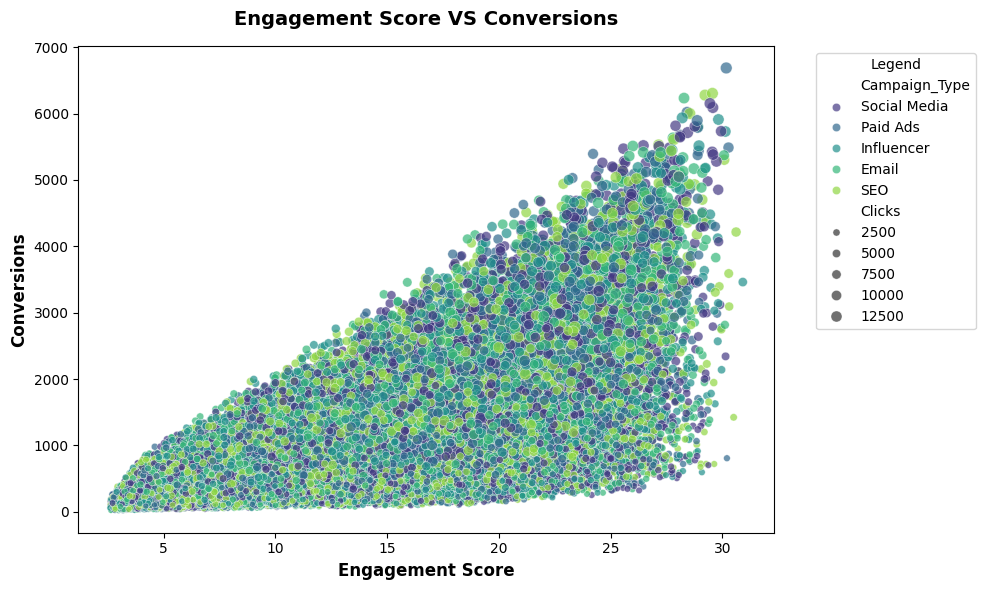

Coeficiente de Correlação entre Engagement_Score e Conversões: 0.64


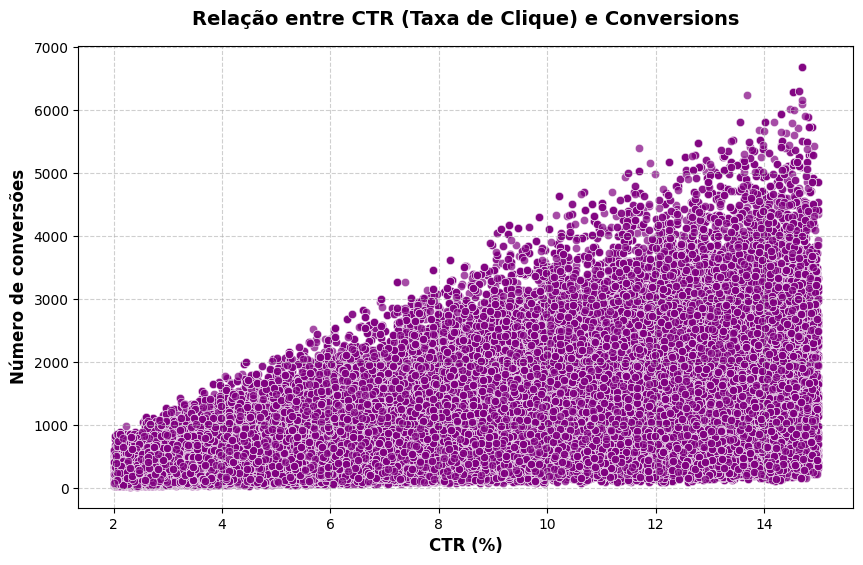

Coeficiente de Correlação entre CTR e Conversões: 0.53


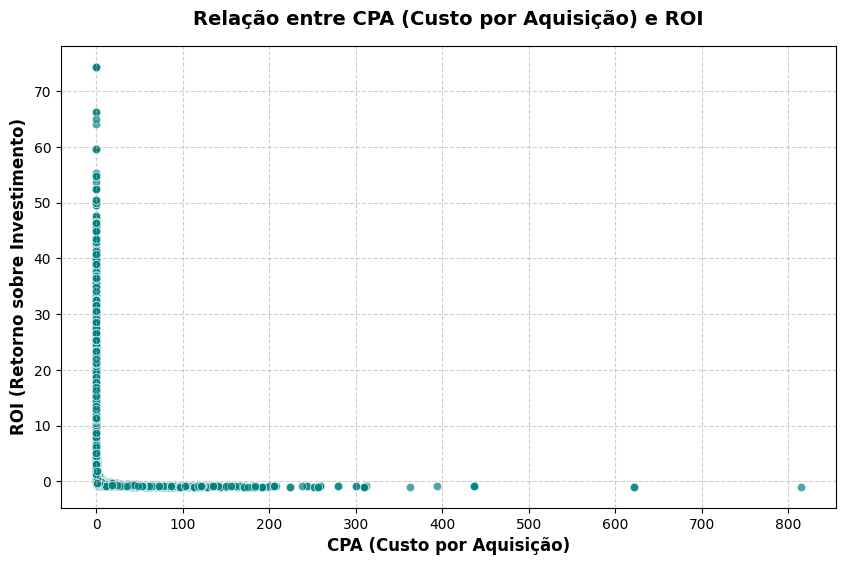

Coeficiente de Correlação entre CPA e ROI: -0.15


In [9]:
# Gráficos

# Engagement x Conversions

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Engagement_Score',
    y='Conversions',
    hue='Campaign_Type',
    size='Clicks',
    alpha=0.7,
    palette='viridis'
)

plt.title('Engagement Score VS Conversions', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Engagement Score', fontsize=12, fontweight='semibold')
plt.ylabel('Conversions', fontsize=12, fontweight='semibold')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Legend')

plt.tight_layout()
plt.show()

correlacao_eng_conv = df_channel_metrics['Engagement_Score'].corr(df_channel_metrics['Conversions'])
print(f'Coeficiente de Correlação entre Engagement_Score e Conversões: {correlacao_eng_conv:.2f}')

# CTR Alto gera mais conversões?

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_channel_metrics, x='CTR', y='Conversions', alpha=0.7, color='purple')

plt.title('Relação entre CTR (Taxa de Clique) e Conversions', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('CTR (%)', fontsize=12, fontweight='semibold')
plt.ylabel('Número de conversões', fontsize=12, fontweight='semibold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

correlacao_ctr_conv = df_channel_metrics['CTR'].corr(df_channel_metrics['Conversions'])
print(f'Coeficiente de Correlação entre CTR e Conversões: {correlacao_ctr_conv:.2f}')

# ROI alto está associado a CPA baixo?

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_channel_metrics, x='CPA', y='ROI', alpha=0.7, color='teal')
plt.title('Relação entre CPA (Custo por Aquisição) e ROI', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('CPA (Custo por Aquisição)', fontsize=12, fontweight='semibold')
plt.ylabel('ROI (Retorno sobre Investimento)', fontsize=12, fontweight='semibold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

correlacao_cpa_roi = df_channel_metrics['CPA'].corr(df_channel_metrics['ROI'])
print(f'Coeficiente de Correlação entre CPA e ROI: {correlacao_cpa_roi:.2f}')

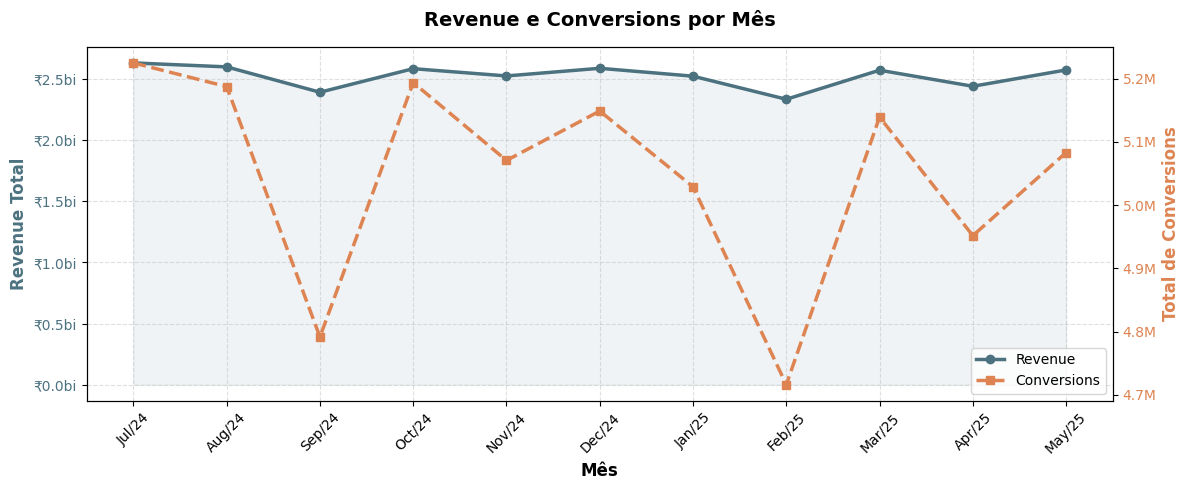

C:\Users\Home\AppData\Local\Temp\ipykernel_11764\4228601844.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


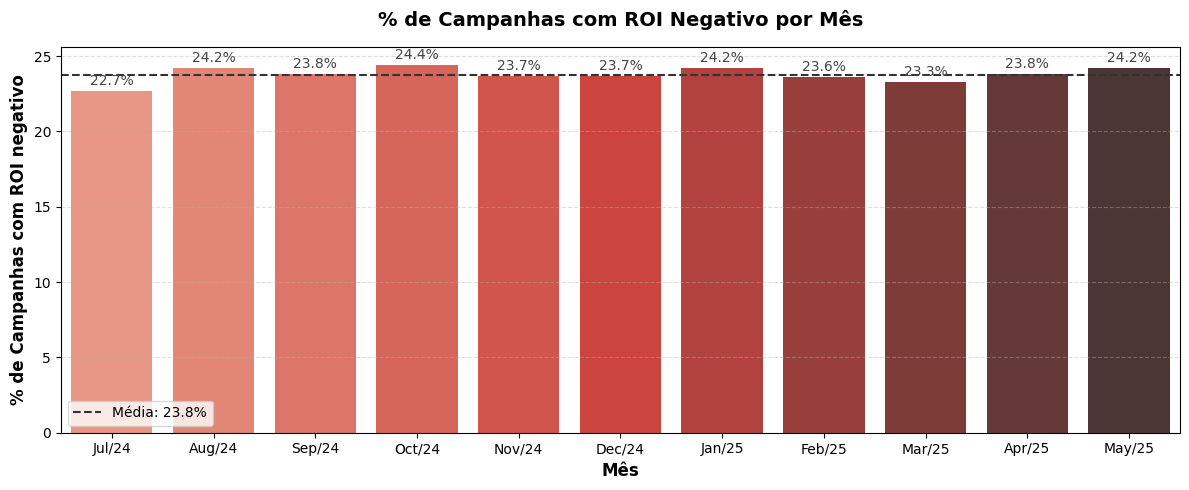

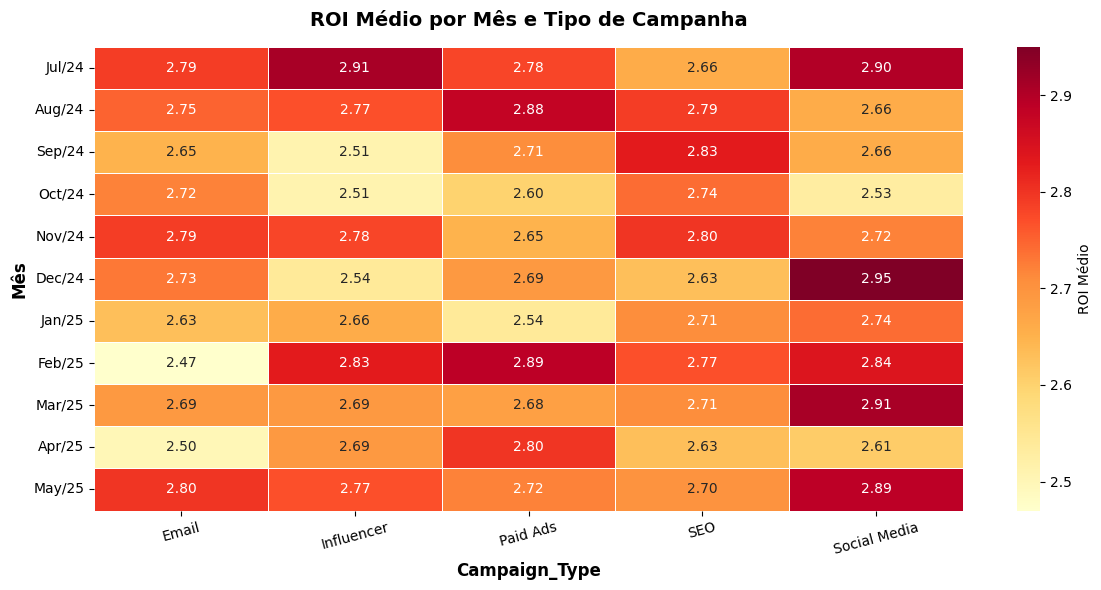

In [10]:
# Análises temporais com gráficos
# Configurando as datas pois o mês de junho de 2025 vai até o dia 24

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.to_period('M')
df['Month_str'] = df['Date'].dt.strftime('%b/%y')

df_completo = df[df['Month'] != pd.Period('2025-06', 'M')]

months_order = df_completo.groupby('Month')['Month_str'].first().tolist()

# Gráfico 1:Revenue e Conversions mensais

df_mensal = df_completo.groupby('Month_str').agg(
    Revenue=('Revenue', 'sum'),
    Conversions=('Conversions', 'sum')
).reindex(months_order)

fig, ax1 = plt.subplots(figsize=(12,5))

color_revenue = '#4C7280'
color_conv = '#DD8452'

ax1.plot(months_order, df_mensal['Revenue'], color=color_revenue,
         marker='o', linewidth=2.5, markersize=6, label='Revenue')
ax1.fill_between(months_order, df_mensal['Revenue'], alpha=0.08, color=color_revenue)
ax1.set_ylabel('Revenue Total', fontsize=12, fontweight='semibold', color=color_revenue)
ax1.tick_params(axis='y', labelcolor=color_revenue)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e9:.1f}bi'))

ax2 = ax1.twinx()
ax2.plot(months_order, df_mensal['Conversions'], color=color_conv,
         marker='s', linewidth=2.5, linestyle='--', label='Conversions')
ax2.set_ylabel('Total de Conversions', fontsize=12, fontweight='semibold', color=color_conv)
ax2.tick_params(axis='y', labelcolor=color_conv)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title('Revenue e Conversions por Mês', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Mês', fontsize=12, fontweight='semibold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()

# Gráfico 2:% de Campanhas com ROI negativo por Mês

df_roi_neg = df_completo.groupby('Month_str').apply(
    lambda x: (x['ROI'] < 0).mean() * 100    
).reindex(months_order).reset_index()
df_roi_neg.columns = ['Month_str', 'pct_roi_neg']
df_roi_neg['pct_roi_neg'] = df_roi_neg['pct_roi_neg'].round(1)

plt.figure(figsize=(12,5))

bars = sns.barplot(
    data=df_roi_neg,
    x='Month_str',
    y='pct_roi_neg',
    palette='Reds_d',
    order=months_order
)

for bar, val in zip(bars.patches, df_roi_neg['pct_roi_neg']):
    bars.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10, color='#444'
    )

plt.axhline(y=df_roi_neg['pct_roi_neg'].mean(), color='#333', linestyle='--',
            linewidth='1.5', label=f'Média: {df_roi_neg['pct_roi_neg'].mean():.1f}%')

plt.title('% de Campanhas com ROI Negativo por Mês', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mês', fontsize=12, fontweight='semibold')
plt.ylabel('% de Campanhas com ROI negativo', fontsize=12, fontweight='semibold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# Gráfico 3:Heatmap de ROI médio por mês X Campaign Type 

df_heatmap = df_completo.groupby(['Month_str', 'Campaign_Type'])['ROI'].mean().round(2).unstack()
df_heatmap = df_heatmap.reindex(months_order)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df_heatmap,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'ROI Médio'}
)

plt.title('ROI Médio por Mês e Tipo de Campanha', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Campaign_Type', fontsize=12, fontweight='semibold')
plt.ylabel('Mês', fontsize=12, fontweight='semibold')
plt.tick_params(axis='x', rotation=15)
plt.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Caixa de insights do projeto

## Separação de tópicos

### EDA: Performance das campanhas , público, canais, custos de aquisição, engajamento e conversão
### Métricas: Análise Estratégicas usando as métricas criadas e já existentes sendo elas ROAS, ROI, Convertion_Rate e CTR
### Gráficos: Engagement_Score x Conversions, CTR x Conversions e CPA x ROI
### Gráficos Temporais: Revenue e Conversions por mês, % de Campanhas com ROI Negativo por Mês e ROI médio por Mês e Tipo de Campanha

## EDA

### Performance das campanhas:

Analisando por ROI, conversão e revenue,
duas campanhas que notoriamente tem resultados muito positivos nestes três segmentos Social Media e Influencer, 
em contrapartida há  que as outras campanhas não são tão bem convertidas e trazem muito menos lucro sendo elas SEO e Email, 
recomenda-se revisar as estratégias aplicadas em SEO e Email antes de manter os investimentos,
avaliando se o retorno justifica o custo.

### Performance do público nas campanhas

O público apresentou um comportamento uniforme nas campanhas, com Engagement_Score médio de 13.74
e a receita total sendo mais de 5 bilhões para todos os segmentos. 
Premium Shoppers se destaca levemente como o segmento de maior receita.
Dado que as diferenças entre públicos são pequenas, recomenda-se aprofundar a segmentação em campanhas futuras
para identificar oportunidades de diferenciação de resultados entre os públicos.

### Eficiência dos canais

Youtube e Instagram lideram em Leads, Conversions e ROI entre os canais analisados,
enquanto Email e Facebook apresentam os menores resultados nas mesmas métricas.
Isso sugere que que a alocação de budget nos canais de maior retorno podem maximizar a eficiência das campanhas.
Recomenda-se priorizar investimento em YouTube e Instagram
e revisar a estratégia aplicada em Email e Facebook antes de continuar investindo nos mesmos níveis.

### Custo de aquisição

Analisando Revenue total e custo de aquisição médio por tipo de campanha,
todos os segmentos apresentam desempenho muito similar - o Acquisition_Cost varia entre 375 e 380.
Influencer e Social Media lideram levemente em revenue, enquanto Email apresenta os menores valores em ambas as métricas.
Dado que as diferenças são pequenas, não há evidência suficiente para recomendar corte de investimento em nenhum tipo de campanha.
Recomenda-se monitorar essas métricas com dados reais para identificar diferenças mais expressivas.

### Engajamento e Conversão

Analisando o Engajamento e Conversão entre Engagement_Score e Conversions foi possível identificar uma correlação moderada entre ambas
que apresentaram um coeficiente de 0.6, indicando uma relação moderada entre as duas métricas — ou seja,
campanhas que geram maior engajamento tendem a converter mais.
Isso sugere que investir em conteúdo que aumente o engajamento do público pode impactar diretamente no volume de conversões.
Os tipos de campanhas também foram analisadas novamente para poder observar como andam as Impressões, Leads e Clicks entre as campanhas.
Dentre elas se destacam novamente Social Media e Influencer tendo em média mais de 55100 de Impressões e mais de 1880 em Leads, 
também foram analisadas os Clicks de forma geral e em média, 
os resultados mostraram que as campanhas Social Media e Influencer destacaram das demais em ambos os segmentos
tendo de forma geral mais de 52.400.000 de clicks e tendo ambas uma média superior a 4700 clicks, acima das demais campanhas.
SEO e Email ficaram para trás em todas as métricas usadas — 
recomenda-se revisão de estratégias de marketing para poder trazer melhores resultados.

## Métricas

### Análise de qual Target_Audience tem maior ROAS médiano

A análise para identificar qual Target_Audience teve maior ROAS médio concluiu que 
'Premium Shopper' lideram com 1829.23, enquanto 'Working Women' e 'Tier 2 City Customers' ficaram abaixo de 1740.00. 
Apesar da diferença existir, ela representam menos de 5% entre o maior e o menor valor —  
o que limita conclusões práticas com base neste dataset. 
Recomenda-se monitorar essas métricas com dados reais para verificar se a diferença entre públicos se acentua e 
justifica uma estratégia de segmentação diferenciada.

### Análise de Campaign_Type X Channel_Used.

Na análise de Campaign_Type X Channel_Used, utilizando ROAS mediano, seguem as conclusões por tipo de campanha —  
aqui vai as conclusões de cada campanha mostrando em qual canal tem os melhores números e os piores números. 
Email: Canal de maior eficiencia: Google com 1839.0 e o pior canal de eficiencia: Facebook com 1661.0 
Influencer: Canal de maior eficiencia: Instagram com 1915.0 e o pior canal de eficiencia: Email com 1654.0 
Paid ADS: Canal de maior eficiencia: YouTube com 1840.0 e o pior canal de eficiencia: Facebook com 1637.0 
SEO: Canal de maior eficiencia: YouTube com 1823.0 e o pior canal de eficiencia: Google com 1701.0 
Social Media: Canal de maior eficiencia: Whatsapp com 1823.0 e o pior canal de eficiencia: Youtube com 1728.0
Vale destacar que o YouTube aparece entre os melhores canais em Paid Ads e SEO, mas como pior em Social Media —
Indicando que a eficiencia do canal depende do tipo de campanha.
Facebook por sua vez aparece entre os piores em dois tipos de campanha. 
Recomenda-se revisar como as campanhas são estruturadas nesses canais antes de redistribuir investimento.

### Análise de campanhas com ROI negativo: Campaign_Type, Channel_Used, Target_Audience e Language

A análise de ROI negativo por tipo de campanha, canal, público e idioma revelou que aproximadamente 23% a 24% das 
campanhas operam com ROI negativo em todas as categorias analisadas, 
sem concentração expressiva em nenhum segmento específico. Paid Ads apresenta a maior proporção com 24.15% e 
Social Media a menor com 23.60% — uma diferença de menos de 1 ponto percentual. 
Isso indica que o problema de campanhas com ROI negativo é estrutural e distribuído, não localizado em um tipo de 
campanha, canal ou público específico. 
Recomenda-se investigar os fatores internos de cada campanha individualmente — como duração, orçamento e criativo — 
em vez de atribuir o problema a uma categoria específica.

### Análise de Audience Match

A análise de Audience Match comparou o público alvo planejado e o público efetivamente atingido pelas campanhas, 
utilizando ROI, CTR e Conversion_Rate como critérios.
Os resultados mostram que 50.1% das campanhas atingiram o público planejado com leve vantagem nas três métricas
em relação às campanhas que não atingiram o público pretendido — porém as diferenças são mínimas.
Recomenda-se que haja uma revisão nas estratégias de segmentação para aumentar a eficácia do direcionamento das 
campanhas ao público alvo, o que pode ampliar as diferenças de performance entre os dois grupos.
 
## Gráficos

### Engagement_Score x Conversions

O gráfico de Engagement_Score X Conversions revela que há uma correlação positiva de 0.64 — ou seja, 
quanto maior o engajamento de uma campanha, maior tende ser o número de conversões. 
Esse padrão é visível na forma do gráfico, que se concentra em uma diagonal crescente: 
campanhas com mais clicks naturalmente acumulam mais engajamento e mais conversões.
Porém uma observação importante aparece nas bordas do gráfico: existem campanhas que, 
apesar de terem menos clicks que a maioria, ainda sim apresentam engajamento acima da média — são poucos casos,
mas indicam que o número de clicks não é o único fator que determina o engajamento. 
Essas campanhas merecem atenção pois podem revelar formatos ou públicos que convertem bem mesmo com menor alcance.

### CTR x Conversions

O gráfico de CTR x Conversions revela uma correlação positiva de 0.53 — quanto maior a taxa de cliques (CTR) 
de uma campanha maior tende a ser o volume de conversões. 
o gráfico apresenta uma diagonal crescente com essa tendencia.
Vale observar que 99% das conversões ficam abaixo dos 4000 e que o CTR das campanhas variam de de 2-15%, 
mostrando que mesmo campanhas com CTR mais alto raramente ultrapassam esse teto de conversões — 
o que reforça a uniformidade já observada no dataset.

### Relação entre CPA e ROI

O Gráfico de CPA x ROI apresenta uma correlação de -0.15 —  quanto maior o custo por aquisição, menor tende a ser o 
retorno da campanha. A grande maioria das campanhas, opera com CPA um custo muito baixo e 
são justamente essas que concentram os melhores ROIs, com média de 2.72. 
Em contrapartida, as poucas campanhas com CPA acima de 100 apresentam um ROI muito baixo — praticamente no prejuízo. 
Isso reforça que controlar o custo por aquisição é diretamente relevante para garantir retorno positivo nas campanhas.

## Gráficos temporais

### Revenue e Conversions por mês

O gráfico de revenue e conversions por mês identifica que há uma correlação direta entre 
a receita e conversões no período de julho de 2024 a maio de 2025 — 
apenas quedas expressivas das conversões para ter um impacto de menor acumulo nas receitas,
mesmo em meses de queda drástica como em setembro de 2024 com menos de 4.8 milhões de conversões
e em fevereiro de 2025 com 4.7 milhões de conversões, as receitas se manteve acima de ₹2.0 bilhões.
Vale ressaltar que o gráfico mostra que, com exceto nos meses de queda das conversões, 
em todos os meses apresentam receitas de ₹2.5 bilhões ou bem proximo a este volume de receitas —
demonstrando consistência e resiliência no faturamento ao longo do período analisado.

### % de Campanhas com ROI Negativo por Mês

O gráfico de % de Campanhas com ROI Negativo por Mês revela algo preocupante:
ao longo de todo período analisado, de julho de 2024 a maio de 2025
a média geral desse ROI Negativo é de 23.8% — ou seja, aproximadamente 1 em cada 4 campanhas operam no prejuízo.
Julho de 2024 foi o único mês com a menor proporção mas sem se distanciar significativamente dos demais.
Isso confirma que o problema é estrutural e não sazonal.
Recomenda-se investigar mais a fundo os fatores internos das campanhas com ROI negativo — 
o que não é possivel concluir com os dados disponíveis neste dataset.

### ROI Médio por Mês e Tipo de Campanha

O heatmap de ROI médio por mês e tipo de campanha mostra que todos os tipos de campanha 
flutuam entre 2.47 e 2.95 ao longo dos meses — sem que nenhum se fixe consistentemente como o melhor ou pior.
Social Media lidera levemente na média geral com 2.76,
seguido de SEO com 2.72, enquanto Email apresenta a menor média com 2.68.
A ausência de um padrão fixo por um tipo de campanha reforça que o ROI é influenciado por fatores além do tipo de 
campanha — como período, público e canal utilizado.